In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from iminuit import Minuit, cost

from matplotlib.markers import MarkerStyle

my_cmap = plt.colormaps["rainbow"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["figure.figsize"]='5,3'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')

r = np.random
r.seed(42)

## #6_3


In [3]:
def likelihood_fct(k,n,p):
    y=stats.binom.pmf(k,n,p)
    return y


def beta_distribution(x,alpha, beta):
    y=stats.beta.pdf(x,alpha,beta)
    return y

def prior_fct(p):
    y=beta_distribution(p,5,17)
    return y


def posterior_fct(p,k=66,n=100):
    y=likelihood_fct(k,n,p)*prior_fct(p)
    return y




def proposal_fct(theta):
    rando=r.normal(loc=0,scale=0.3)
    #print("proposal fct: theta, rando:",theta,rando)
    sum=theta+rando
    if sum<0 or sum>1:
        return proposal_fct(theta)
    #print("selected theta,rando, sum:",theta,rando,sum)
    return sum



def acceptance_fct(x,x_next,ratio):
    if ratio>=1:
        return x_next
    else:
        if np.random.rand()<ratio:
            return x_next
        else:
            return x


In [4]:
theta_start=0.1
theta_array=[]

#create proposal
for i in range(2000):
    theta_prop=proposal_fct(theta_start)
    #print(f"start: {theta_start}, next: {next_theta}")


    #calculate acceptance ratio
    post_next=posterior_fct(theta_prop)
    post_start=posterior_fct(theta_start)
    ratio=post_next/post_start
    #print(f"ratio: {ratio}, post start: {post_st},post next: {post_ne}")

    next_theta=acceptance_fct(theta_start,theta_prop,ratio)

    theta_start=next_theta
    theta_array.append(next_theta)





Text(0.5, 0, 'iteration')

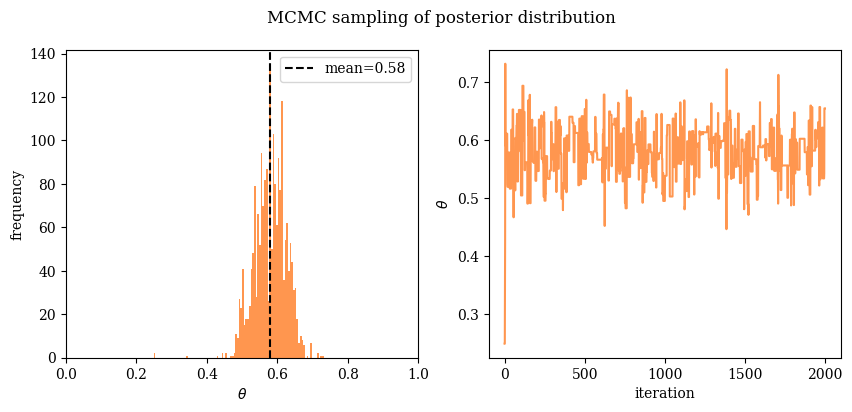

In [5]:
fig,ax=plt.subplots(1,2,figsize=(10,4))
ax[0].hist(theta_array[:],bins=100,density=False, color=my_cmap(0.8))#, edgecolor='black')
ax[0].set_xlabel(r"$\theta$")
ax[0].set_ylabel("frequency")
mean=np.mean(theta_array[:])
ax[0].axvline(x=mean,color="black",linestyle="--",label=f"mean={mean:.2f}")
ax[0].legend()
fig.suptitle("MCMC sampling of posterior distribution")
ax[0].set_xlim(0,1)

ax[1].plot(theta_array[:],color=my_cmap(0.8))
ax[1].set_ylabel(r"$\theta$")
ax[1].set_xlabel("iteration")

## #4 redo with external package

In [11]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

# True parameter values
alpha_true, sigma_true = 1, 1
beta_true = [1, 2.5]

# Size of dataset
size = 100

# Predictor variable
X1 = np.random.randn(size)
X2 = np.random.randn(size) * 0.2

# Simulate outcome variable
Y = alpha_true + beta_true[0] * X1 + beta_true[1] * X2 + rng.normal(size=size) * sigma_true

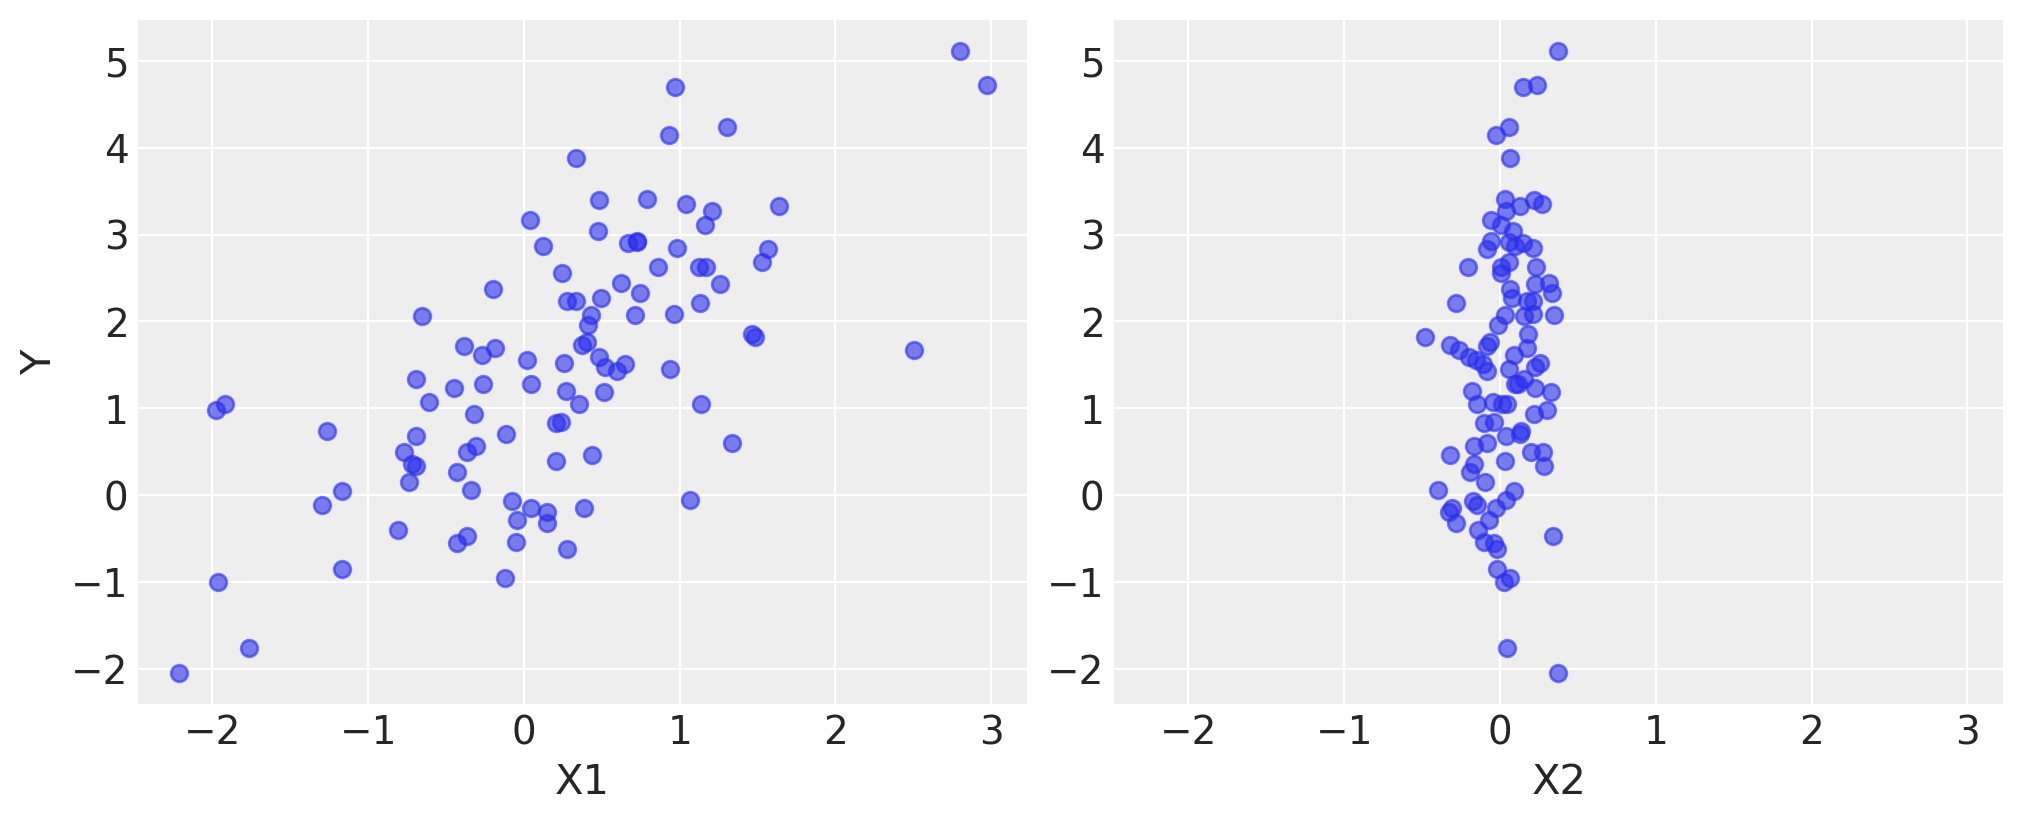

In [3]:
fig, axes = plt.subplots(1, 2, sharex=True, figsize=(10, 4))
axes[0].scatter(X1, Y, alpha=0.6)
axes[1].scatter(X2, Y, alpha=0.6)
axes[0].set_ylabel("Y")
axes[0].set_xlabel("X1")
axes[1].set_xlabel("X2");

In [4]:
import pymc as pm

basic_model = pm.Model()

with basic_model:
    # Priors for unknown model parameters
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta = pm.Normal("beta", mu=0, sigma=10, shape=2)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Expected value of outcome
    mu = alpha + beta[0] * X1 + beta[1] * X2

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=Y)

In [ ]:
with basic_model:
    # draw 1000 posterior samples
    idata = pm.sample(chains=3, draws=1000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (5 chains in 2 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 5 chains for 1_000 tune and 1_000 draw iterations (5_000 + 5_000 draws total) took 25 seconds.


In [6]:
idata

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [7]:
idata.posterior["alpha"].sel(draw=slice(0, 4))

<xarray.DataArray 'alpha' (chain: 5, draw: 5)> Size: 200B
array([[1.08404677, 1.19684512, 0.90294709, 1.39692155, 1.36867761],
       [1.14690806, 1.18561586, 1.28741246, 1.00394616, 1.24525182],
       [1.05950634, 1.28177466, 1.19707467, 1.04109841, 1.04078241],
       [1.22817694, 1.08167883, 1.20926417, 1.11068111, 1.06627738],
       [0.92849776, 1.30007719, 1.33429783, 1.31142422, 0.91251126]])
Coordinates:
  * chain    (chain) int64 40B 0 1 2 3 4
  * draw     (draw) int64 40B 0 1 2 3 4

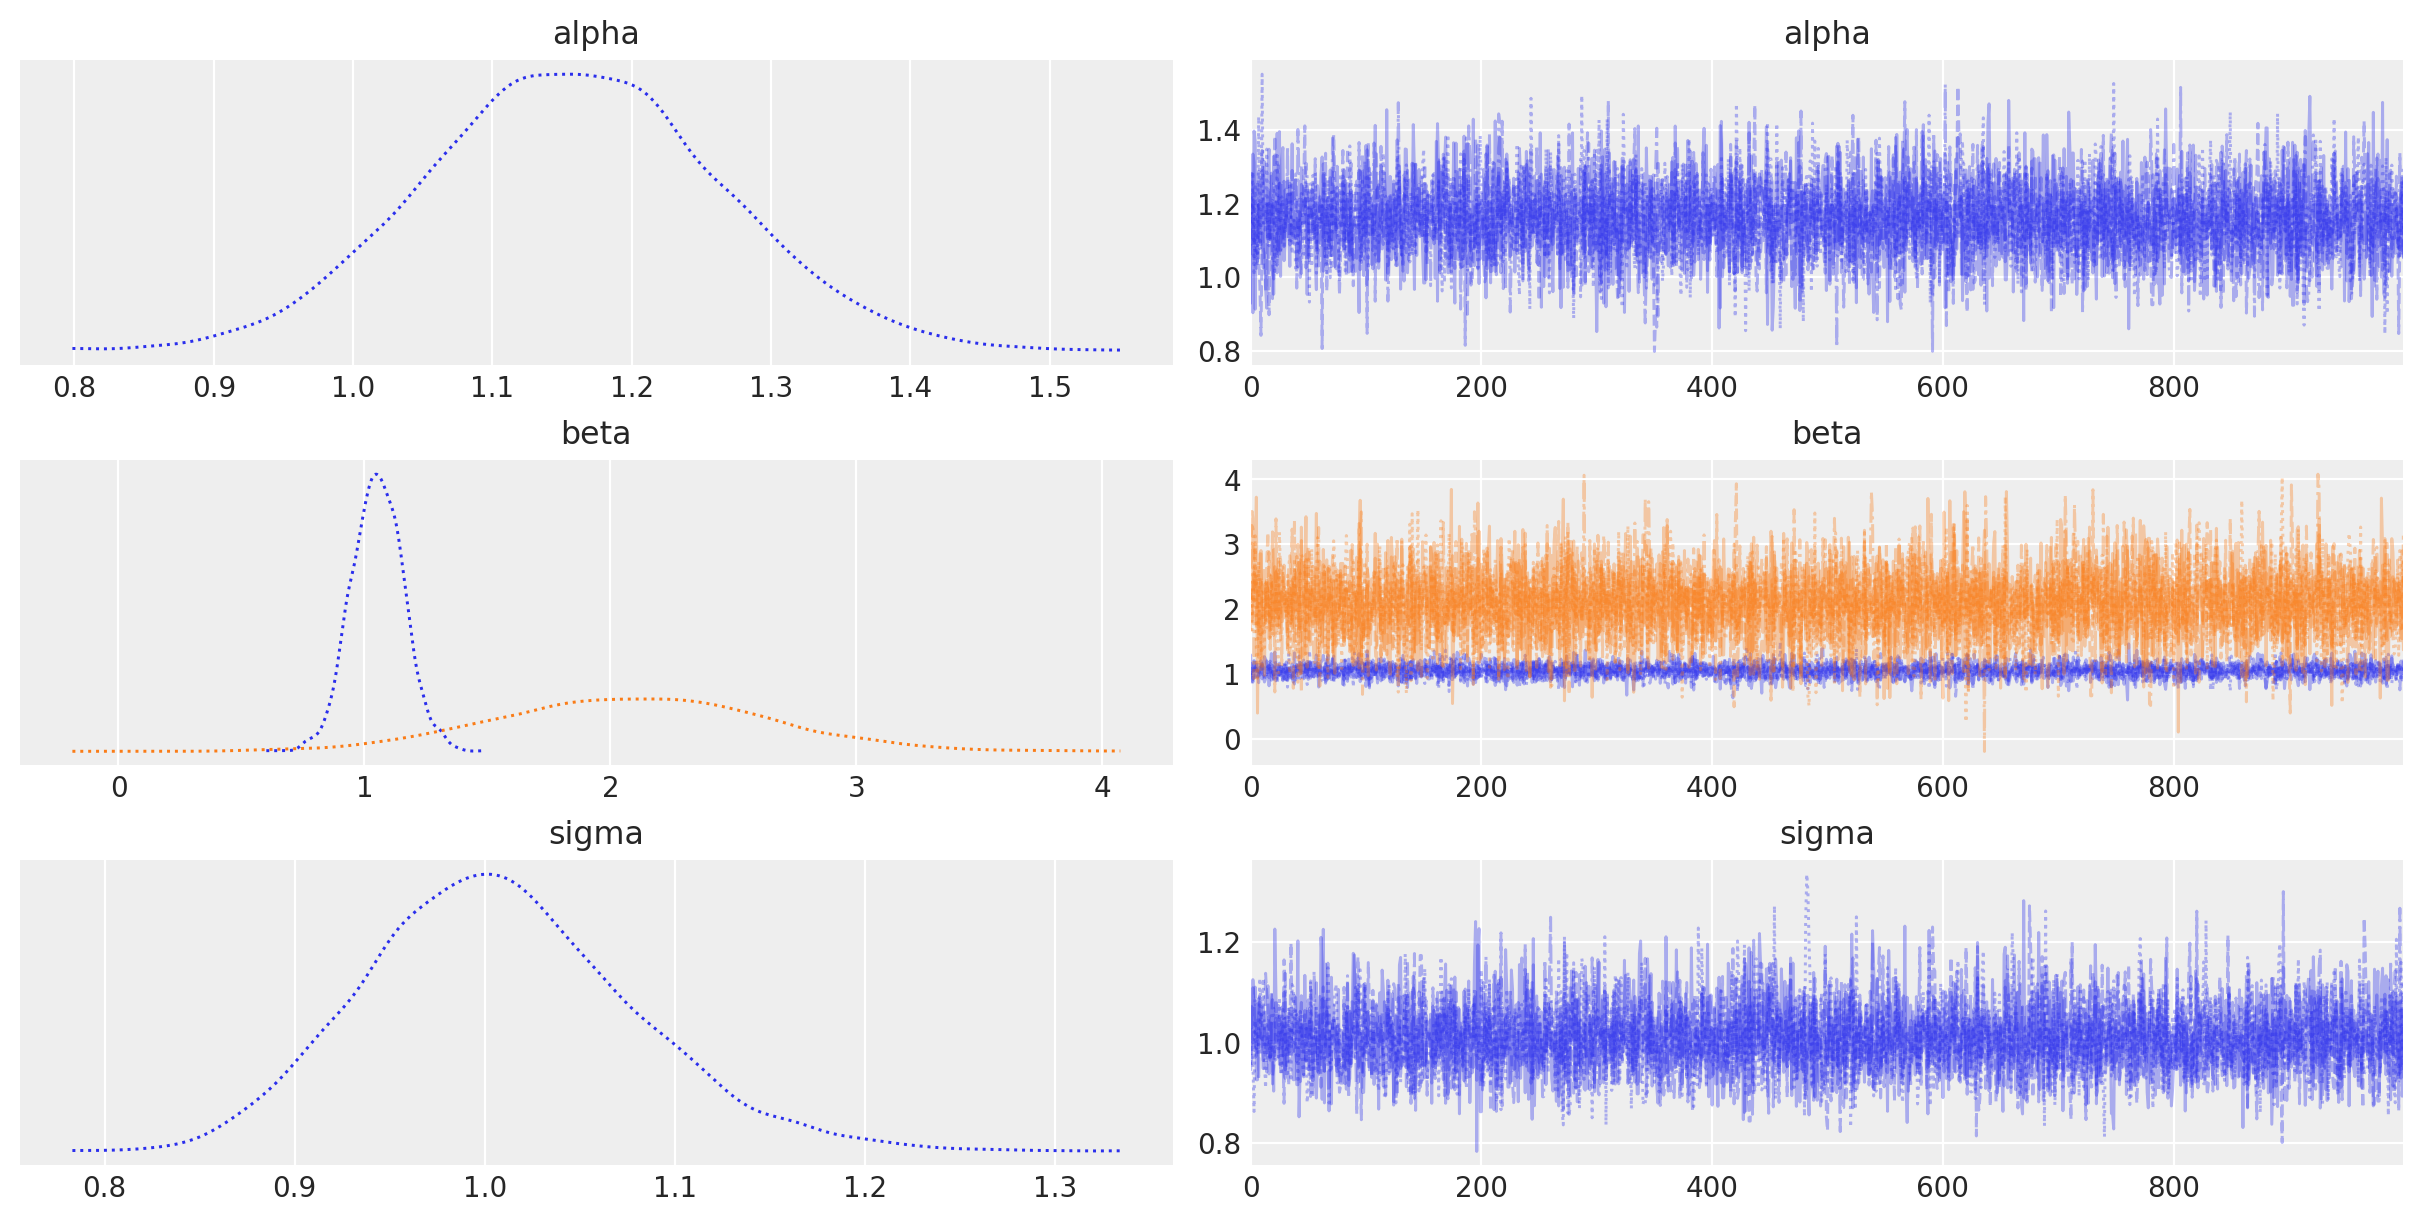

In [8]:
az.plot_trace(idata, combined=True);

In [ ]:
az.summary(idata, round_to=2)

print("alpha true value:", alpha_true)
print("beta true value:", beta_true)
print("sigma true value:", sigma_true)